### Importando libs

In [24]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.23 🚀 Python-3.10.20 torch-2.10.0+cu128 CPU (13th Gen Intel Core i7-13650HX)
Setup complete ✅ (20 CPUs, 15.3 GB RAM, 151.6/936.8 GB disk)


/home/felipe/miniconda3/envs/pothole-detection/lib/python3.10/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [25]:
from ultralytics import YOLO

from ultralytics import settings
settings.update({"mlflow": True})

In [13]:
import fiftyone as fo
print(fo.__version__)

import fiftyone.zoo as foz
from fiftyone import ViewField as F
import fiftyone.brain as fob

import sys
from pathlib import Path

1.13.4


In [14]:
root_dir = str(Path().resolve().parent) 

if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

In [15]:
sys.path

['/home/felipe/Documentos/Projetos/pothole-detection',
 '/home/felipe/miniconda3/envs/pothole-detection/lib/python310.zip',
 '/home/felipe/miniconda3/envs/pothole-detection/lib/python3.10',
 '/home/felipe/miniconda3/envs/pothole-detection/lib/python3.10/lib-dynload',
 '',
 '/home/felipe/miniconda3/envs/pothole-detection/lib/python3.10/site-packages',
 '/home/felipe/miniconda3/envs/pothole-detection/lib/python3.10/site-packages/setuptools/_vendor']

In [16]:
Path.cwd().parent

PosixPath('/home/felipe/Documentos/Projetos/pothole-detection')

In [17]:
dataset_dir = Path.cwd().parent / "data/Pothole.v1-raw.yolo26/"
yaml_dir = Path.cwd().parent / "data/Pothole.v1-raw.yolo26/data.yaml"
print(dataset_dir)
print(yaml_dir)

/home/felipe/Documentos/Projetos/pothole-detection/data/Pothole.v1-raw.yolo26
/home/felipe/Documentos/Projetos/pothole-detection/data/Pothole.v1-raw.yolo26/data.yaml


In [18]:
fo.list_datasets()

['pothole-yolo26', 'quickstart']

In [19]:
# fo.delete_dataset('pothole-yolo26')

### Carregando imagens e criando dataset

In [42]:
dataset_train = fo.Dataset.from_dir(
    dataset_dir='../data/Pothole.v1-raw.yolo26/',
    dataset_type=fo.types.YOLOv5Dataset,
    split="train",
    name="pothole-yolo26",
    yaml_path = yaml_dir
)

 100% |█████████████████| 465/465 [513.9ms elapsed, 0s remaining, 906.9 samples/s]     


In [43]:
dataset_train

Name:        pothole-yolo26
Media type:  image
Num samples: 465
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

### Embeddings
* Carregando modelo CLIP ViT
* Calculando os embeddings
* Redimensionando as dimensões

In [44]:
clip = foz.load_zoo_model("clip-vit-base32-torch")

In [45]:
dataset_train.compute_embeddings(
    clip,
    embeddings_field="clip_embeddings"
)

 100% |█████████████████| 465/465 [2.8s elapsed, 0s remaining, 205.5 samples/s]      


In [46]:
fob.compute_visualization(
    dataset_train,
    embeddings="clip_embeddings",
    method="tsne",
    brain_key="clip_tsne"
)

dataset_train

Generating visualization...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 465 samples in 0.000s...
[t-SNE] Computed neighbors for 465 samples in 0.135s...
[t-SNE] Computed conditional probabilities for sample 465 / 465
[t-SNE] Mean sigma: 1.788479
[t-SNE] Computed conditional probabilities in 0.006s
[t-SNE] Iteration 50: error = 64.4143600, gradient norm = 0.2338395 (50 iterations in 0.021s)
[t-SNE] Iteration 100: error = 65.3562927, gradient norm = 0.2712742 (50 iterations in 0.021s)
[t-SNE] Iteration 150: error = 66.0752945, gradient norm = 0.2400546 (50 iterations in 0.022s)
[t-SNE] Iteration 200: error = 64.3927612, gradient norm = 0.2688973 (50 iterations in 0.023s)
[t-SNE] Iteration 250: error = 65.1978836, gradient norm = 0.2155748 (50 iterations in 0.022s)
[t-SNE] KL divergence after 250 iterations with early exaggeration: 65.197884
[t-SNE] Iteration 300: error = 0.9853454, gradient norm = 0.0045628 (50 iterations in 0.018s)
[t-SNE] Iteration 350: error = 0.9288551,

Name:        pothole-yolo26
Media type:  image
Num samples: 465
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    clip_embeddings:  fiftyone.core.fields.VectorField

In [47]:
session = fo.launch_app(dataset_train)

### Carregando dataset de treinamento com embeddings calculados

In [7]:
dataset_train = fo.load_dataset('pothole-yolo26')

In [8]:
dataset_train

Name:        pothole-yolo26
Media type:  image
Num samples: 465
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    clip_embeddings:  fiftyone.core.fields.VectorField


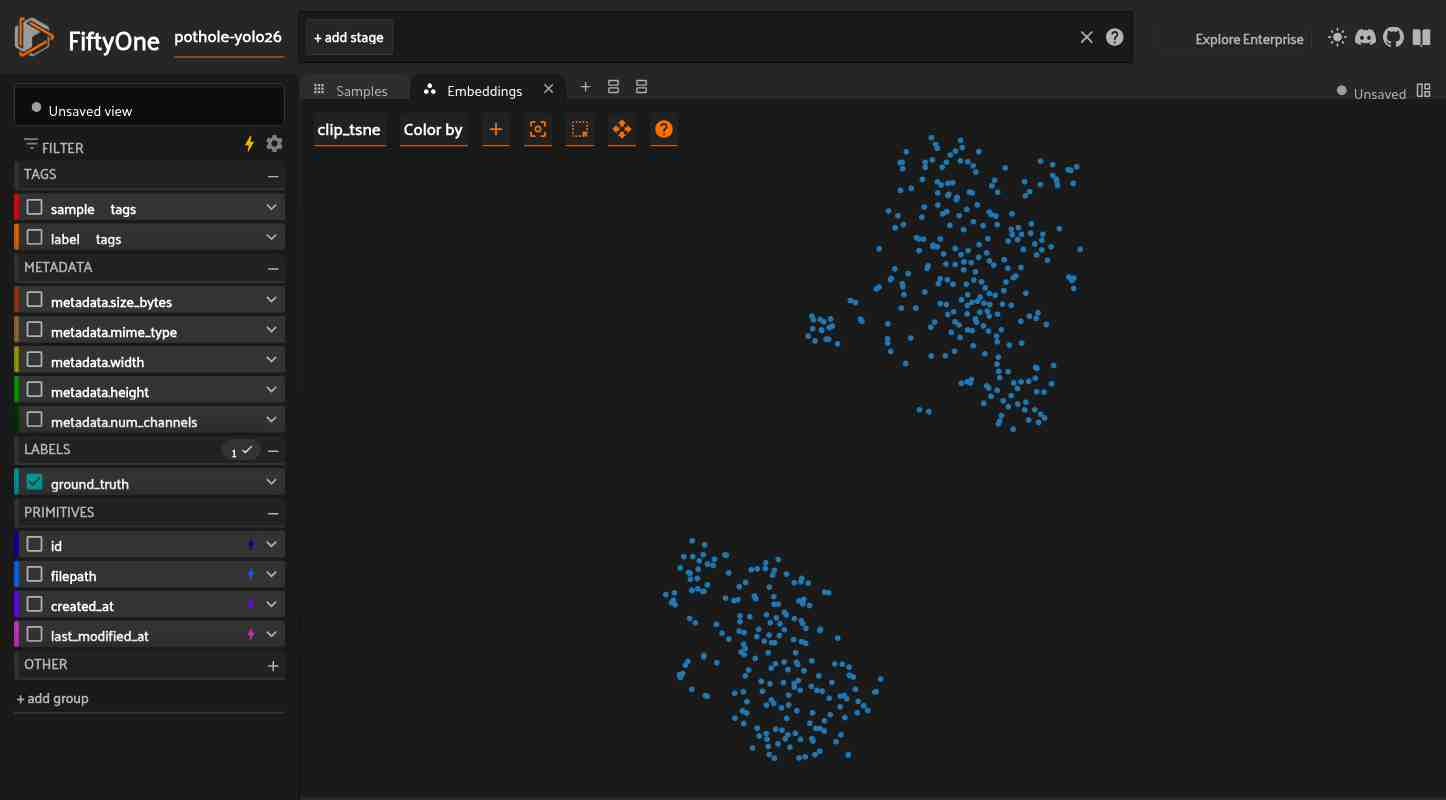

In [9]:
session = fo.launch_app(dataset_train)

#### Prevendo dataset de teste para avaliação/visualização

In [26]:
model_with_finetuning = YOLO("runs/detect/yolo26_projeto_pothole/experimento_15/weights/best.pt")

In [22]:
dataset_test = fo.Dataset.from_dir(
    dataset_dir='../data/Pothole.v1-raw.yolo26/',
    dataset_type=fo.types.YOLOv5Dataset,
    split="test",
    name="pothole-test-yolo26",
    yaml_path = yaml_dir
)

 100% |███████████████████| 67/67 [82.0ms elapsed, 0s remaining, 817.2 samples/s]  


In [27]:
dataset_test.apply_model(model_with_finetuning, label_field="predictions")

 100% |███████████████████| 67/67 [3.5s elapsed, 0s remaining, 20.8 samples/s]      


In [28]:
dataset_test

Name:        pothole-test-yolo26
Media type:  image
Num samples: 67
Persistent:  False
Tags:        []
Sample fields:
    id:               fiftyone.core.fields.ObjectIdField
    filepath:         fiftyone.core.fields.StringField
    tags:             fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:         fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:       fiftyone.core.fields.DateTimeField
    last_modified_at: fiftyone.core.fields.DateTimeField
    ground_truth:     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    predictions:      fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)

In [ ]:
session = fo.launch_app(dataset_test)